# Bitcoin analytics

In [1]:
import pandas as pd
import os

In [2]:
files = [file for file in os.listdir("./bitcoin_data")]

bitcoin_data = pd.DataFrame()

for file in files:
    df = pd.read_csv("./bitcoin_data/"+file)
    bitcoin_data = pd.concat([bitcoin_data, df])
    
bitcoin_data.to_csv("bitcoin_data.csv", index=False)

### Please refer here:
https://stackoverflow.com/questions/3207219/how-do-i-list-all-files-of-a-directory

This will allow us to read all files in the directory.

### Please also refer here:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html

This will allow us to join the datasheets that we've just read.

In [3]:
bitcoindata = pd.read_csv("bitcoin_data.csv")
bitcoindata

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-09-30,123.654990,124.304660,124.751660,122.563490
1,BTC,2013-10-01,125.455000,123.654990,125.758500,123.633830
2,BTC,2013-10-02,108.584830,125.455000,125.665660,83.328330
3,BTC,2013-10-03,118.674660,108.584830,118.675000,107.058160
4,BTC,2013-10-04,121.338660,118.674660,121.936330,118.005660
...,...,...,...,...,...,...
2568,BTC,2020-10-21,13102.934462,11920.411389,13109.165972,11900.213839
2569,BTC,2020-10-22,13140.669284,12801.688068,13192.252868,12697.457047
2570,BTC,2020-10-23,12933.823565,12980.880103,13029.963892,12731.057793
2571,BTC,2020-10-24,13081.672559,12929.849401,13168.338828,12877.938014


We need to add some content to the dataframe before we answer questions. First, let's list out the columns that we have.

In [4]:
bitcoindata.columns

Index(['Currency', 'Date', 'Closing Price (USD)', '24h Open (USD)',
       '24h High (USD)', '24h Low (USD)'],
      dtype='object')

We need to add three more columns: 'Yearly', 'Monthly', 'Quarterly'.

In [5]:
bitcoindata['Yearly'] = bitcoindata['Date'].str[0:4]
bitcoindata

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD),Yearly
0,BTC,2013-09-30,123.654990,124.304660,124.751660,122.563490,2013
1,BTC,2013-10-01,125.455000,123.654990,125.758500,123.633830,2013
2,BTC,2013-10-02,108.584830,125.455000,125.665660,83.328330,2013
3,BTC,2013-10-03,118.674660,108.584830,118.675000,107.058160,2013
4,BTC,2013-10-04,121.338660,118.674660,121.936330,118.005660,2013
...,...,...,...,...,...,...,...
2568,BTC,2020-10-21,13102.934462,11920.411389,13109.165972,11900.213839,2020
2569,BTC,2020-10-22,13140.669284,12801.688068,13192.252868,12697.457047,2020
2570,BTC,2020-10-23,12933.823565,12980.880103,13029.963892,12731.057793,2020
2571,BTC,2020-10-24,13081.672559,12929.849401,13168.338828,12877.938014,2020


In [6]:
bitcoindata['Monthly'] = bitcoindata['Date'].str[0:4]+bitcoindata['Date'].str[5:7]
bitcoindata

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD),Yearly,Monthly
0,BTC,2013-09-30,123.654990,124.304660,124.751660,122.563490,2013,201309
1,BTC,2013-10-01,125.455000,123.654990,125.758500,123.633830,2013,201310
2,BTC,2013-10-02,108.584830,125.455000,125.665660,83.328330,2013,201310
3,BTC,2013-10-03,118.674660,108.584830,118.675000,107.058160,2013,201310
4,BTC,2013-10-04,121.338660,118.674660,121.936330,118.005660,2013,201310
...,...,...,...,...,...,...,...,...
2568,BTC,2020-10-21,13102.934462,11920.411389,13109.165972,11900.213839,2020,202010
2569,BTC,2020-10-22,13140.669284,12801.688068,13192.252868,12697.457047,2020,202010
2570,BTC,2020-10-23,12933.823565,12980.880103,13029.963892,12731.057793,2020,202010
2571,BTC,2020-10-24,13081.672559,12929.849401,13168.338828,12877.938014,2020,202010


In [7]:
bitcoindata.loc[(bitcoindata['Monthly'].str[4:6] == '01')|(bitcoindata['Monthly'].str[4:6] == '02')|(bitcoindata['Monthly'].str[4:6] == '03'), 'Quarterly'] = bitcoindata['Date'].str[0:4]+'Q1'
bitcoindata.loc[(bitcoindata['Monthly'].str[4:6] == '04')|(bitcoindata['Monthly'].str[4:6] == '05')|(bitcoindata['Monthly'].str[4:6] == '06'), 'Quarterly'] = bitcoindata['Date'].str[0:4]+'Q2'
bitcoindata.loc[(bitcoindata['Monthly'].str[4:6] == '07')|(bitcoindata['Monthly'].str[4:6] == '08')|(bitcoindata['Monthly'].str[4:6] == '09'), 'Quarterly'] = bitcoindata['Date'].str[0:4]+'Q3'
bitcoindata.loc[(bitcoindata['Monthly'].str[4:6] == '10')|(bitcoindata['Monthly'].str[4:6] == '11')|(bitcoindata['Monthly'].str[4:6] == '12'), 'Quarterly'] = bitcoindata['Date'].str[0:4]+'Q4'

bitcoindata

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD),Yearly,Monthly,Quarterly
0,BTC,2013-09-30,123.654990,124.304660,124.751660,122.563490,2013,201309,2013Q3
1,BTC,2013-10-01,125.455000,123.654990,125.758500,123.633830,2013,201310,2013Q4
2,BTC,2013-10-02,108.584830,125.455000,125.665660,83.328330,2013,201310,2013Q4
3,BTC,2013-10-03,118.674660,108.584830,118.675000,107.058160,2013,201310,2013Q4
4,BTC,2013-10-04,121.338660,118.674660,121.936330,118.005660,2013,201310,2013Q4
...,...,...,...,...,...,...,...,...,...
2568,BTC,2020-10-21,13102.934462,11920.411389,13109.165972,11900.213839,2020,202010,2020Q4
2569,BTC,2020-10-22,13140.669284,12801.688068,13192.252868,12697.457047,2020,202010,2020Q4
2570,BTC,2020-10-23,12933.823565,12980.880103,13029.963892,12731.057793,2020,202010,2020Q4
2571,BTC,2020-10-24,13081.672559,12929.849401,13168.338828,12877.938014,2020,202010,2020Q4


Let's also rename our columns to make it easier.

In [8]:
bitcoindata.rename(columns = {'Closing Price (USD)':'Closing', '24h Open (USD)':'Opening', '24h High (USD)':'High', '24h Low (USD)':'Low'}, inplace=True)
bitcoindata

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
0,BTC,2013-09-30,123.654990,124.304660,124.751660,122.563490,2013,201309,2013Q3
1,BTC,2013-10-01,125.455000,123.654990,125.758500,123.633830,2013,201310,2013Q4
2,BTC,2013-10-02,108.584830,125.455000,125.665660,83.328330,2013,201310,2013Q4
3,BTC,2013-10-03,118.674660,108.584830,118.675000,107.058160,2013,201310,2013Q4
4,BTC,2013-10-04,121.338660,118.674660,121.936330,118.005660,2013,201310,2013Q4
...,...,...,...,...,...,...,...,...,...
2568,BTC,2020-10-21,13102.934462,11920.411389,13109.165972,11900.213839,2020,202010,2020Q4
2569,BTC,2020-10-22,13140.669284,12801.688068,13192.252868,12697.457047,2020,202010,2020Q4
2570,BTC,2020-10-23,12933.823565,12980.880103,13029.963892,12731.057793,2020,202010,2020Q4
2571,BTC,2020-10-24,13081.672559,12929.849401,13168.338828,12877.938014,2020,202010,2020Q4


## Let's start answering some questions:

### What does the overall Bitcoin price index look like?

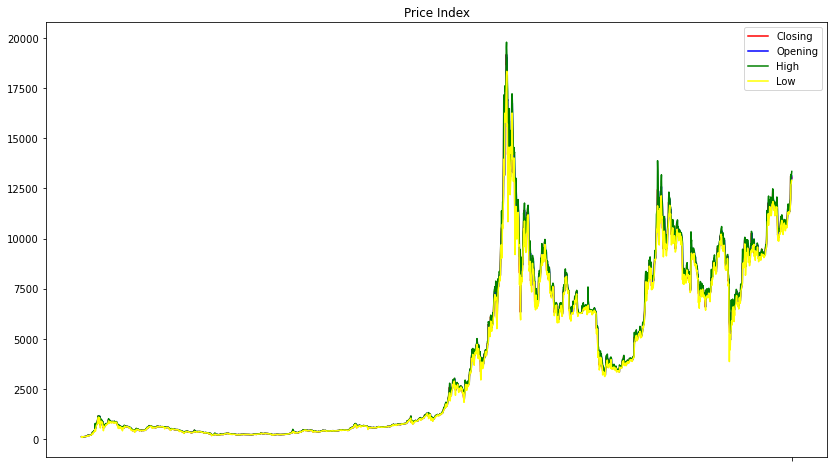

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(bitcoindata.Date, bitcoindata.Closing, label='Closing', color='red')
plt.plot(bitcoindata.Date, bitcoindata.Opening, label='Opening', color='blue')
plt.plot(bitcoindata.Date, bitcoindata.High, label='High', color='green')
plt.plot(bitcoindata.Date, bitcoindata.Low, label='Low', color='yellow')

plt.xticks('')
plt.legend()

plt.show()

### What does the overall Bitcoin price index look like per year? per quarter? per month?

In [10]:
bitcoindata.groupby(['Yearly']).mean()

,Closing,Opening,High,Low
Yearly,,,,
2013,492.041447,485.115606,519.044394,448.604202
2014,526.335662,527.571837,539.874378,512.593876
2015,272.548397,272.232906,278.182428,266.335513
2016,567.676750,566.223289,573.977324,558.570542
2017,3986.021947,3951.843611,4132.673853,3782.607896
2018,7531.113095,7557.328136,7780.823214,7299.147779
2019,7360.325081,7347.568799,7538.928398,7147.470331
2020,9398.357062,9375.352285,9571.426436,9164.143369


In [11]:
bitcoindata.groupby(['Quarterly']).mean()

,Closing,Opening,High,Low
Quarterly,,,,
2013Q3,123.654990,124.304660,124.751660,122.563490
2013Q4,496.045647,489.037464,523.330185,452.148122
2014Q1,704.163737,707.536269,727.499064,679.198610
2014Q2,518.257466,516.254801,530.334669,503.783592
2014Q3,531.371494,534.188695,541.214646,523.416657
2014Q4,355.327973,356.096843,364.424239,347.502722
2015Q1,251.028482,251.849607,259.069906,243.898176
2015Q2,236.546946,236.344587,239.374382,233.453050
2015Q3,254.821321,255.088339,258.594095,250.849294


In [12]:
bitcoindata.groupby(['Monthly']).mean()

,Closing,Opening,High,Low
Monthly,,,,
201309,123.654990,124.304660,124.751660,122.563490
201310,151.855872,149.456071,154.576018,144.982100
201311,538.260015,508.211001,560.034675,478.247872
201312,799.382808,810.063822,856.563876,734.056323
201401,859.370984,856.824016,881.562527,829.781661
...,...,...,...,...
202006,9484.776959,9493.996580,9624.590106,9286.053964
202007,9606.707487,9529.629320,9689.265225,9423.438678
202008,11649.978639,11642.595267,11833.590586,11404.544773


At a first glance, it looks like there have been four major periods to Bitcoin's price fluctuations: <br>
1) The flat period before the first spike. <br>
2) The first spike and crash. <br>
3) The lull followed by the second spike. <br>
4) The rapid crash followed by its more rapid recovery.

Let's look at the flat period.

### What does the Bitcoin price index look like during the "flat" period?

In [13]:
flatdaterange = bitcoindata.loc[(bitcoindata['Monthly'] <= '201702')]

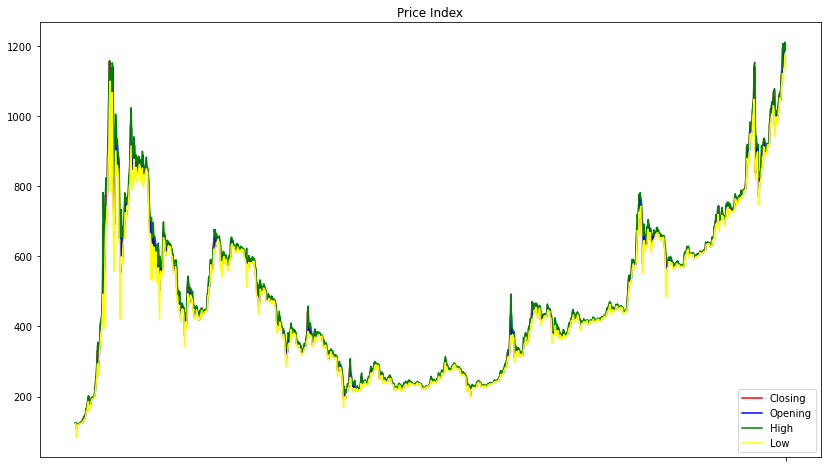

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(flatdaterange.Date, flatdaterange.Closing, label='Closing', color='red')
plt.plot(flatdaterange.Date, flatdaterange.Opening, label='Opening', color='blue')
plt.plot(flatdaterange.Date, flatdaterange.High, label='High', color='green')
plt.plot(flatdaterange.Date, flatdaterange.Low, label='Low', color='yellow')

plt.xticks('')
plt.legend()

plt.show()

The flat period looked at closer wasn't so flat at all, and a huge part of that was due to a single person running bots that ended up acquiring over 600,000 Bitcoins exchanging at the now-defunct Mt. Gox.

https://www.cnbc.com/2018/01/23/one-person-caused-bitcoin-to-spike-from-150-to-1000-in-2013.html

This inflated the price of Bitcoin from \\$150 to over \\$1,000, and Mt. Gox would later shut down after it was discovered Bitcoins were stolen from the company's wallet as early as 2011.

### When did it finally bottom out?

In [15]:
bottoming = bitcoindata.loc[(bitcoindata['Monthly'] >= '201401') & (bitcoindata['Monthly'] <= '201702')]
bottoming.sort_values(by='Closing', ascending=True).head(10)

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
471,BTC,2015-01-14,193.35110,219.12800,219.97300,170.08400,2015,201501,2015Q1
474,BTC,2015-01-17,195.59467,209.16550,209.32420,194.95780,2015,201501,2015Q1
693,BTC,2015-08-24,203.18133,227.23233,227.23233,198.22833,2015,201508,2015Q3
473,BTC,2015-01-16,209.16550,220.57450,222.01380,199.17810,2015,201501,2015Q1
476,BTC,2015-01-19,211.54010,212.27110,216.68050,206.65940,2015,201501,2015Q1
475,BTC,2015-01-18,212.27110,195.59467,218.98480,194.55010,2015,201501,2015Q1
477,BTC,2015-01-20,212.28249,211.54010,214.66619,204.80010,2015,201501,2015Q1
488,BTC,2015-01-31,216.66066,226.94116,233.52791,215.00708,2015,201501,2015Q1
499,BTC,2015-02-11,218.72833,223.00366,223.00924,218.27583,2015,201502,2015Q1
470,BTC,2015-01-13,219.12800,243.08100,249.04299,216.35600,2015,201501,2015Q1


With the exception of one day in August 2015, the price of Bitcoin bottomed out in January 2015.

### How long did it take for Bitcoin to hit \\$1,000 again after that?

In [16]:
bottoming.loc[(bitcoindata['Closing'] > 1000)]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
1189,BTC,2017-01-01,1009.97375,964.32500,1011.52500,963.53000,2017,201701,2017Q1
1190,BTC,2017-01-02,1028.33375,1009.97375,1034.10500,998.62125,2017,201701,2017Q1
1191,BTC,2017-01-03,1047.09999,1028.33375,1048.12375,1013.37750,2017,201701,2017Q1
1192,BTC,2017-01-04,1140.38500,1047.09999,1141.99750,1047.06375,2017,201701,2017Q1
1221,BTC,2017-02-02,1020.09000,982.82750,1020.12375,982.33375,2017,201702,2017Q1
1222,BTC,2017-02-03,1011.21500,1020.09000,1024.14250,995.87000,2017,201702,2017Q1
1223,BTC,2017-02-04,1029.40124,1011.21500,1040.08625,1004.37750,2017,201702,2017Q1
1224,BTC,2017-02-05,1019.31250,1029.40124,1030.33625,1006.51875,2017,201702,2017Q1
1225,BTC,2017-02-06,1029.40875,1019.31250,1030.40500,1018.23000,2017,201702,2017Q1
1226,BTC,2017-02-07,1067.70875,1029.40875,1067.79625,1029.40875,2017,201702,2017Q1


Bitcoin would close over \\$1,000 for the first time in two years at the very start of 2017.

### How long did it take for Bitcoin to double its value and enter its first spike?

In [17]:
bitcoindata.loc[(bitcoindata['Monthly'] >= '201701') & (bitcoindata['Closing'] > 2000)].head(1)

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
1328,BTC,2017-05-20,2074.69625,1983.97875,2074.69625,1964.975,2017,201705,2017Q2


Until the near the end of May that year. 20th May became the first time Bitcoin closed at over \\$2,000.

### What was the average monthly price of Bitcoin during those five months?

In [18]:
surge = bitcoindata.loc[(bitcoindata['Monthly'] >= '201701') & (bitcoindata['Monthly'] <= '201705')]
surge.groupby(['Monthly']).mean()

,Closing,Opening,High,Low
Monthly,,,,
201701,912.383306,912.101371,936.381694,881.324718
201702,1065.387660,1057.511017,1077.984768,1038.779687
201703,1127.592546,1131.336224,1164.591546,1093.428354
201704,1221.113624,1211.339190,1231.560965,1198.746114
201705,1903.975442,1870.706571,1963.131626,1803.801975


This shows that price manipulation finally crept up again around May 2015, because the previous four months only had incremental growth instead. As a matter of fact, we know this is definitely price manipulation as reported by The Independent:

https://www.independent.co.uk/life-style/gadgets-and-tech/news/bitcoin-price-record-2017-buy-cryptocurrency-whale-a9185451.html

Now let's look at the first spike.

### What did the Bitcoin price index look like from March 2017 to March 2018?

In [19]:
firstspikedaterange = bitcoindata.loc[(bitcoindata['Monthly'] >= '201703') & (bitcoindata['Monthly'] <= '201803')]

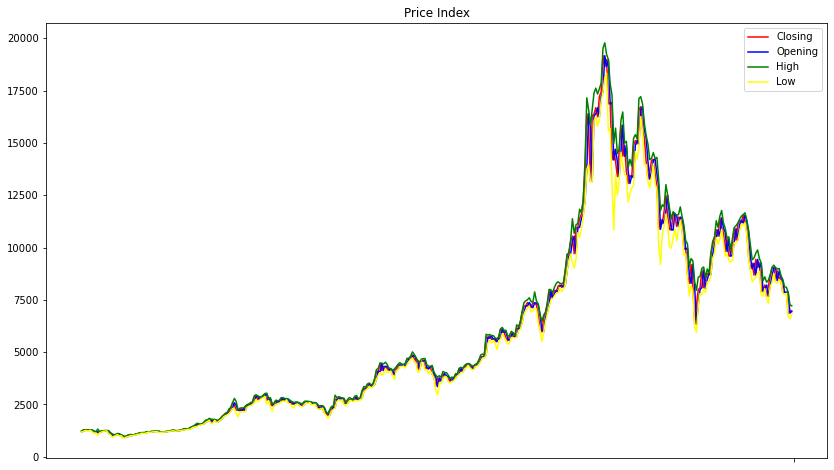

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(firstspikedaterange.Date, firstspikedaterange.Closing, label='Closing', color='red')
plt.plot(firstspikedaterange.Date, firstspikedaterange.Opening, label='Opening', color='blue')
plt.plot(firstspikedaterange.Date, firstspikedaterange.High, label='High', color='green')
plt.plot(firstspikedaterange.Date, firstspikedaterange.Low, label='Low', color='yellow')

plt.xticks('')
plt.legend()

plt.show()

### Which months did the first spike peak?

In [21]:
bitcoindata.groupby(['Monthly']).mean()[49:55]

,Closing,Opening,High,Low
Monthly,,,,
201710,5349.193910,5280.678951,5451.353911,5153.793346
201711,7835.135500,7725.749208,8092.623875,7454.319458
201712,14942.157338,14821.727862,15781.762258,13830.786786
201801,12804.021048,12915.927782,13472.895081,12129.863790
201802,9378.356517,9364.723035,9906.351873,8846.966874
201803,8922.208588,9032.697983,9360.843829,8614.268548


We see it's December 2017 and January 2018, which those two months are the very peak of the spike.

In [22]:
bitcoindata.loc[(bitcoindata['Monthly'] == '201712')|(bitcoindata['Monthly'] == '201801') & (bitcoindata['Closing'] > 10000)]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
1523,BTC,2017-12-01,10923.20125,9706.10375,11082.27000,9421.45624,2017,201712,2017Q4
1524,BTC,2017-12-02,10973.54375,10923.20125,11156.14500,10705.12999,2017,201712,2017Q4
1525,BTC,2017-12-03,11382.20875,10973.54375,11831.51250,10495.56250,2017,201712,2017Q4
1526,BTC,2017-12-04,11597.23125,11382.20875,11662.84375,10875.71375,2017,201712,2017Q4
1527,BTC,2017-12-05,12230.36500,11597.23125,12273.54000,11473.50875,2017,201712,2017Q4
1528,BTC,2017-12-06,13734.52000,12230.36500,14097.04000,12152.10750,2017,201712,2017Q4
1529,BTC,2017-12-07,16403.42125,13734.52000,17153.94125,13731.82000,2017,201712,2017Q4
1530,BTC,2017-12-08,15732.10000,16403.42125,16590.21375,13963.52875,2017,201712,2017Q4
1531,BTC,2017-12-09,13152.52875,15732.10000,15859.42375,13152.52875,2017,201712,2017Q4
1532,BTC,2017-12-10,16299.29750,13152.52875,16587.84250,13152.52875,2017,201712,2017Q4


This shows the peak at December 16th, 2017, though the 17th and 18th were still extremely high. But the question is...

### How high did it get during those three days?

In [23]:
bitcoindata.loc[(bitcoindata['Date'] == '2017-12-16')|(bitcoindata['Date'] == '2017-12-17')|(bitcoindata['Date'] == '2017-12-18')][['Date','Closing','Opening','High','Low']]

,Date,Closing,Opening,High,Low
1538,2017-12-16,19166.97874,17436.59750,19521.78250,17436.59750
1539,2017-12-17,18640.26250,19166.97874,19783.20625,18094.19374
1540,2017-12-18,18984.76750,18640.26250,19227.08250,18329.14500


At the very, very peak, Bitcoin almost hit \\$20,000 on the 17th, but it closed out lower than its opening unlike the other two days. The overall highs, lows, openings, and closings were all over the place for these three days, which points back to the article above on how much manipulation was going on behind the scenes.

While 18th December's difference between high and low are slightly under \\$1,000, 17th December's difference pushes nearly to \\$2,000 and 18th December's difference safely crosses past \\$2,000.

### Have any other dates besides those three dates reached 16th December's low?

In [24]:
bitcoindata.loc[(bitcoindata['High'] > 17436.59750)]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
1534,BTC,2017-12-12,16678.28749,16374.89750,17615.47250,16259.27750,2017,201712,2017Q4
1536,BTC,2017-12-14,17221.65125,16246.13875,17583.20000,16152.01375,2017,201712,2017Q4
1537,BTC,2017-12-15,17436.59750,17221.65125,17872.55500,16999.70375,2017,201712,2017Q4
1538,BTC,2017-12-16,19166.97874,17436.59750,19521.78250,17436.59750,2017,201712,2017Q4
1539,BTC,2017-12-17,18640.26250,19166.97874,19783.20625,18094.19374,2017,201712,2017Q4
1540,BTC,2017-12-18,18984.76750,18640.26250,19227.08250,18329.14500,2017,201712,2017Q4
1541,BTC,2017-12-19,16862.57125,18984.76750,18984.76750,15577.74250,2017,201712,2017Q4
1542,BTC,2017-12-20,16925.01750,16862.57125,17822.56625,15683.86125,2017,201712,2017Q4


That means there are only five days that their high was higher than December 16th's low, and all of them are dates that are around that week. Now let's see when are the closest dates outside of that week.

### What are the top five dates that approaches December 2017's high?

In [25]:
bitcoindata.loc[(bitcoindata['High'] < 17436.59750) & (bitcoindata['Monthly'] != '201712') & (bitcoindata['Monthly'] != '201801')].sort_values(by='High',ascending=False).head(5)

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2086,BTC,2019-06-26,12444.925860,11668.665857,13879.237706,11625.881090,2019,201906,2019Q2
2572,BTC,2020-10-25,13008.453258,13115.833520,13342.750281,12906.700592,2020,202010,2020Q4
2087,BTC,2019-06-27,11086.268829,12444.922343,13328.580313,10314.753873,2019,201906,2019Q2
2569,BTC,2020-10-22,13140.669284,12801.688068,13192.252868,12697.457047,2020,202010,2020Q4
2100,BTC,2019-07-10,12054.183793,12585.241974,13175.687737,11566.898394,2019,201907,2019Q3


It would take until the middle of 2019 for the price of Bitcoin to even get close to the artifically inflated height of December 2017, and even then, the middle of 2019 high is still about \\$4,000 below the very low of 16th December.

### When did this first spike bottom out?

In [26]:
firstspikebottoming = bitcoindata.loc[(bitcoindata['Monthly'] >= '201801') & (bitcoindata['Monthly'] <= '201906')]
firstspikebottoming.sort_values(by='Closing', ascending=True).head(10)

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
1895,BTC,2018-12-15,3194.962272,3212.207159,3227.867420,3122.342716,2018,201812,2018Q4
1896,BTC,2018-12-16,3200.642468,3178.299355,3256.600326,3176.353015,2018,201812,2018Q4
1894,BTC,2018-12-14,3212.207081,3262.271683,3300.651394,3138.099494,2018,201812,2018Q4
1893,BTC,2018-12-13,3263.547913,3427.049729,3435.142473,3233.263656,2018,201812,2018Q4
1947,BTC,2019-02-07,3360.534076,3365.529473,3380.783837,3349.755990,2019,201902,2019Q1
1891,BTC,2018-12-11,3360.946628,3409.162882,3428.100418,3294.037452,2018,201812,2018Q4
1946,BTC,2019-02-06,3367.519032,3428.981335,3441.920460,3344.124422,2019,201902,2019Q1
1887,BTC,2018-12-07,3391.874146,3578.207206,3621.501257,3201.762797,2018,201812,2018Q4
1938,BTC,2019-01-29,3395.018645,3429.707749,3438.068371,3346.143188,2019,201901,2019Q1
1943,BTC,2019-02-03,3404.499313,3433.044895,3487.571973,3386.579366,2019,201902,2019Q1


It looks like the first spike finally bottomed out a year after it hits its peak in December 2018.

In [27]:
bitcoindata.loc[(bitcoindata['Monthly'] >= '201812') & (bitcoindata['Monthly'] <= '201903')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
1881,BTC,2018-12-01,4178.603828,3953.521462,4251.369948,3904.394191,2018,201812,2018Q4
1882,BTC,2018-12-02,4118.518242,4138.477060,4255.954021,4038.098584,2018,201812,2018Q4
1883,BTC,2018-12-03,3847.032737,4092.851115,4104.858957,3755.326092,2018,201812,2018Q4
1884,BTC,2018-12-04,3889.292120,3847.020460,4034.531558,3724.003343,2018,201812,2018Q4
1885,BTC,2018-12-05,3713.573383,3889.292261,3913.531776,3675.541484,2018,201812,2018Q4
...,...,...,...,...,...,...,...,...,...
1995,BTC,2019-03-27,4018.590510,3925.865359,4030.357641,3914.577708,2019,201903,2019Q1
1996,BTC,2019-03-28,4008.370872,4018.590510,4033.386524,3990.008616,2019,201903,2019Q1
1997,BTC,2019-03-29,4080.260114,4008.371070,4100.149119,4006.619169,2019,201903,2019Q1
1998,BTC,2019-03-30,4081.221605,4090.750409,4128.415102,4030.061257,2019,201903,2019Q1


This bottoming would continue on for another three months or so.

In [28]:
bitcoindata.loc[(bitcoindata['Monthly'] == '201904')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2000,BTC,2019-04-01,4135.184940,4094.704791,4148.661800,4052.601676,2019,201904,2019Q2
2001,BTC,2019-04-02,4818.770635,4135.182905,4961.780306,4132.556660,2019,201904,2019Q2
2002,BTC,2019-04-03,5102.150753,4818.773504,5325.233877,4810.244974,2019,201904,2019Q2
2003,BTC,2019-04-04,4875.599431,4966.901630,5071.589614,4787.707994,2019,201904,2019Q2
2004,BTC,2019-04-05,5030.933271,4875.596147,5060.703203,4875.596147,2019,201904,2019Q2
2005,BTC,2019-04-06,5028.321082,5032.791239,5229.957551,4934.263044,2019,201904,2019Q2
2006,BTC,2019-04-07,5198.173170,5028.320269,5247.464931,5019.333332,2019,201904,2019Q2
2007,BTC,2019-04-08,5260.205043,5192.929096,5343.247093,5088.678145,2019,201904,2019Q2
2008,BTC,2019-04-09,5179.997649,5260.200329,5285.863420,5117.006185,2019,201904,2019Q2
2009,BTC,2019-04-10,5283.543758,5179.996674,5450.989154,5170.615377,2019,201904,2019Q2


### Which months did the second spike peak?

In [29]:
bitcoindata.groupby(['Monthly']).mean()[67:75]

,Closing,Opening,High,Low
Monthly,,,,
201904,5142.579588,5099.181304,5239.493710,5013.451133
201905,7294.604996,7187.231208,7475.403851,6977.087423
201906,9374.736571,9296.223042,9702.963290,9004.175226
201907,10673.747850,10688.809803,11056.434861,10223.107717
201908,10622.695459,10639.355105,10878.351180,10317.675317
201909,9794.481489,9834.303614,9980.864954,9542.205445
201910,8392.320274,8351.260298,8608.994297,8178.855497
201911,8338.880314,8388.345744,8523.630427,8152.222369


From June to September. That was when Bitcoin hovered around \\$10,000 and surpassing it again.

### How high did the price of Bitcoin get from June to September?

In [30]:
secondpeak = bitcoindata.loc[(bitcoindata['Monthly'] >= '201906') & (bitcoindata['Monthly'] <= '201909')]
secondpeak.sort_values(by='High', ascending=False).head(10)

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2086,BTC,2019-06-26,12444.925860,11668.665857,13879.237706,11625.881090,2019,201906,2019Q2
2087,BTC,2019-06-27,11086.268829,12444.922343,13328.580313,10314.753873,2019,201906,2019Q2
2100,BTC,2019-07-10,12054.183793,12585.241974,13175.687737,11566.898394,2019,201907,2019Q3
2099,BTC,2019-07-09,12575.904067,12335.991553,12815.679036,12127.712182,2019,201907,2019Q3
2088,BTC,2019-06-28,12316.953012,11086.235715,12402.043512,10789.984140,2019,201906,2019Q2
2089,BTC,2019-06-29,12024.080972,12360.187098,12381.041702,11368.274496,2019,201906,2019Q2
2098,BTC,2019-07-08,12335.999395,11422.141159,12354.463032,11335.163950,2019,201907,2019Q3
2127,BTC,2019-08-06,11310.187224,11811.803563,12314.107665,11219.403783,2019,201908,2019Q3
2101,BTC,2019-07-11,11324.144697,12054.182806,12188.177843,11011.041120,2019,201907,2019Q3
2090,BTC,2019-06-30,10932.310507,12024.094522,12187.306699,10837.560065,2019,201906,2019Q2


<b>\\$13879.237706.</b>

Bitcoin quickly climbed over \\$13,000 on 26th June and 27th June before dipping, but it returned on 9th July and 10th July. Reasons why? It's not entirely clear, though part of it has to do with Facebook announcing Libra, part of it has to do with regulators taking a more keen look into cryptocurrency and therefore lending it more legitimacy, and part of it has to do with a weakening dollar.

https://www.cnn.com/2019/06/26/business/bitcoin-value-trnd/index.html

Following these new highs, Bitcoin faced two small peaks and troughs before clashing for a short time.

### When were the small peaks and troughs that followed right after?

In [31]:
peakstroughs = bitcoindata.loc[(bitcoindata['Monthly'] >= '201910') & (bitcoindata['Monthly'] <= '202003')]

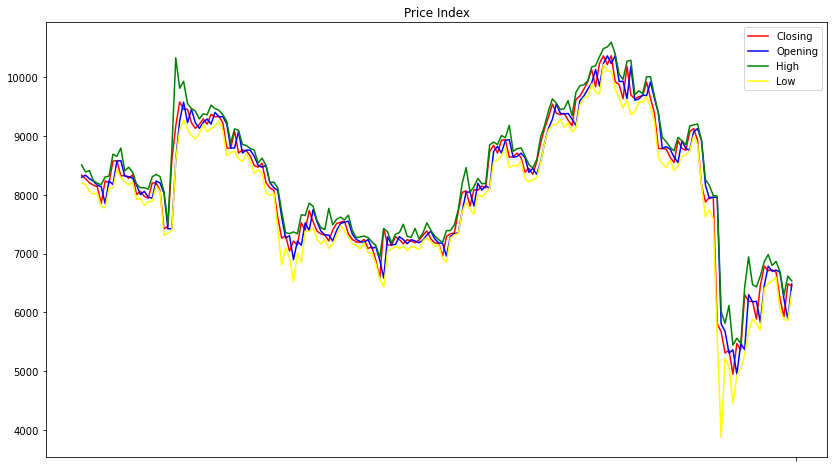

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(peakstroughs.Date, peakstroughs.Closing, label='Closing', color='red')
plt.plot(peakstroughs.Date, peakstroughs.Opening, label='Opening', color='blue')
plt.plot(peakstroughs.Date, peakstroughs.High, label='High', color='green')
plt.plot(peakstroughs.Date, peakstroughs.Low, label='Low', color='yellow')

plt.xticks('')
plt.legend()

plt.show()

In [33]:
bitcoindata.loc[(bitcoindata['Monthly'] == '201910')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2183,BTC,2019-10-01,8333.689190,8298.624775,8508.705409,8195.045244,2019,201910,2019Q4
2184,BTC,2019-10-02,8273.464018,8333.710296,8388.015862,8177.694601,2019,201910,2019Q4
2185,BTC,2019-10-03,8203.843833,8273.457419,8412.650047,8060.325317,2019,201910,2019Q4
2186,BTC,2019-10-04,8163.902638,8231.786249,8240.948769,8014.419323,2019,201910,2019Q4
2187,BTC,2019-10-05,8137.146689,8163.901441,8196.249514,8025.500462,2019,201910,2019Q4
2188,BTC,2019-10-06,7853.693305,8138.833489,8171.568254,7802.464851,2019,201910,2019Q4
2189,BTC,2019-10-07,8236.208379,7850.684576,8304.140139,7777.631571,2019,201910,2019Q4
2190,BTC,2019-10-08,8201.637818,8236.205875,8316.990673,8113.111805,2019,201910,2019Q4
2191,BTC,2019-10-09,8572.380812,8173.838803,8691.072691,8117.912240,2019,201910,2019Q4
2192,BTC,2019-10-10,8582.144518,8572.382301,8654.382776,8435.186510,2019,201910,2019Q4


In [34]:
bitcoindata.loc[(bitcoindata['Monthly'] == '201911')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2213,BTC,2019-11-01,9197.632345,9131.417153,9291.117644,9047.176594,2019,201911,2019Q4
2214,BTC,2019-11-02,9290.896602,9230.478858,9377.084522,9197.833142,2019,201911,2019Q4
2215,BTC,2019-11-03,9202.415451,9290.899794,9362.633137,9074.382879,2019,201911,2019Q4
2216,BTC,2019-11-04,9369.628081,9203.826007,9526.165195,9125.861531,2019,201911,2019Q4
2217,BTC,2019-11-05,9326.599624,9404.380870,9466.070961,9173.044686,2019,201911,2019Q4
2218,BTC,2019-11-06,9335.752402,9326.592531,9439.215735,9254.732115,2019,201911,2019Q4
2219,BTC,2019-11-07,9226.485821,9331.215796,9364.590814,9088.107628,2019,201911,2019Q4
2220,BTC,2019-11-08,8794.358645,9205.618606,9247.614352,8666.389614,2019,201911,2019Q4
2221,BTC,2019-11-09,8798.042055,8794.362610,8881.909087,8719.961753,2019,201911,2019Q4
2222,BTC,2019-11-10,9081.186878,8798.036067,9123.338511,8742.737626,2019,201911,2019Q4


In [35]:
bitcoindata.loc[(bitcoindata['Monthly'] == '201912')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2243,BTC,2019-12-01,7381.963008,7542.245344,7564.940079,7238.322233,2019,201912,2019Q4
2244,BTC,2019-12-02,7333.432930,7381.962005,7440.615736,7162.492125,2019,201912,2019Q4
2245,BTC,2019-12-03,7315.367765,7315.439203,7407.410775,7238.730592,2019,201912,2019Q4
2246,BTC,2019-12-04,7213.733762,7315.369274,7767.908725,7089.141289,2019,201912,2019Q4
2247,BTC,2019-12-05,7398.787050,7213.743416,7488.137772,7155.119946,2019,201912,2019Q4
2248,BTC,2019-12-06,7511.880583,7392.910937,7583.387456,7304.070441,2019,201912,2019Q4
2249,BTC,2019-12-07,7532.123513,7511.884605,7619.666018,7475.015594,2019,201912,2019Q4
2250,BTC,2019-12-08,7550.239200,7532.123513,7573.156018,7387.154016,2019,201912,2019Q4
2251,BTC,2019-12-09,7333.096043,7550.238815,7652.742606,7285.227768,2019,201912,2019Q4
2252,BTC,2019-12-10,7239.762575,7333.095889,7394.504676,7161.527291,2019,201912,2019Q4


In [36]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202001')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2274,BTC,2020-01-01,7174.744012,7179.957689,7237.014866,7152.992402,2020,202001,2020Q1
2275,BTC,2020-01-02,6955.487580,7174.712357,7190.188749,6914.857474,2020,202001,2020Q1
2276,BTC,2020-01-03,7291.219505,6955.487580,7390.041835,6852.093401,2020,202001,2020Q1
2277,BTC,2020-01-04,7337.636670,7291.217504,7390.762935,7263.178696,2020,202001,2020Q1
2278,BTC,2020-01-05,7347.433264,7337.421391,7487.333871,7316.763370,2020,202001,2020Q1
2279,BTC,2020-01-06,7713.860754,7351.578890,7749.648613,7339.702523,2020,202001,2020Q1
2280,BTC,2020-01-07,8039.603701,7714.908484,8192.158877,7708.885351,2020,202001,2020Q1
2281,BTC,2020-01-08,8067.606369,8046.802943,8463.183418,7871.035499,2020,202001,2020Q1
2282,BTC,2020-01-09,7808.701364,8046.111529,8046.283882,7755.401227,2020,202001,2020Q1
2283,BTC,2020-01-10,8087.452885,7808.703733,8136.499126,7670.457792,2020,202001,2020Q1


In [37]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202002')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2305,BTC,2020-02-01,9363.193383,9388.879070,9451.064580,9284.410559,2020,202002,2020Q1
2306,BTC,2020-02-02,9385.260386,9375.226831,9465.487907,9150.534573,2020,202002,2020Q1
2307,BTC,2020-02-03,9269.707035,9385.259769,9603.105582,9222.946494,2020,202002,2020Q1
2308,BTC,2020-02-04,9177.894637,9286.207776,9349.247058,9072.588214,2020,202002,2020Q1
2309,BTC,2020-02-05,9625.456637,9177.895794,9745.171377,9147.652281,2020,202002,2020Q1
2310,BTC,2020-02-06,9681.377411,9600.403585,9856.447773,9527.151669,2020,202002,2020Q1
2311,BTC,2020-02-07,9795.344066,9681.377700,9872.616069,9653.132962,2020,202002,2020Q1
2312,BTC,2020-02-08,9927.778256,9795.343586,9939.671501,9660.309157,2020,202002,2020Q1
2313,BTC,2020-02-09,10132.706499,9900.684635,10175.907011,9888.154765,2020,202002,2020Q1
2314,BTC,2020-02-10,9838.900016,10132.706479,10197.199283,9752.195757,2020,202002,2020Q1


In [38]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202003')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2334,BTC,2020-03-01,8548.948322,8639.592081,8747.725718,8412.723329,2020,202003,2020Q1
2335,BTC,2020-03-02,8923.044398,8549.045999,8977.333203,8491.456295,2020,202003,2020Q1
2336,BTC,2020-03-03,8791.112058,8916.739890,8919.263748,8652.809024,2020,202003,2020Q1
2337,BTC,2020-03-04,8756.961062,8791.112073,8852.256660,8682.684594,2020,202003,2020Q1
2338,BTC,2020-03-05,9078.578777,8756.962116,9172.138258,8745.992956,2020,202003,2020Q1
2339,BTC,2020-03-06,9126.636822,9073.160134,9191.150340,9004.944712,2020,202003,2020Q1
2340,BTC,2020-03-07,8925.213488,9126.888318,9204.672359,8858.647557,2020,202003,2020Q1
2341,BTC,2020-03-08,8166.313894,8925.217518,8925.383039,8163.682472,2020,202003,2020Q1
2342,BTC,2020-03-09,7875.750875,8166.313268,8256.125507,7625.189619,2020,202003,2020Q1
2343,BTC,2020-03-10,7959.228274,7939.252823,8159.157919,7745.152079,2020,202003,2020Q1


From looking at the data from October 2019 to February 2020, there was a very small time period for two days in late October where the price dipped to around \\$7,000 before quickly rebounding past \\$9,000. This rebound would dip again in late November back down to \\$7,000 before maintaining this level until early January of next year. From then, the price of Bitcoin would get as high as over \\$10,000 before the COVID crash in March.

Let's look at the COVID crash.

### What did the Bitcoin price index look like during the COVID crash?

In [39]:
covid = bitcoindata.loc[(bitcoindata['Monthly'] == '202003')]

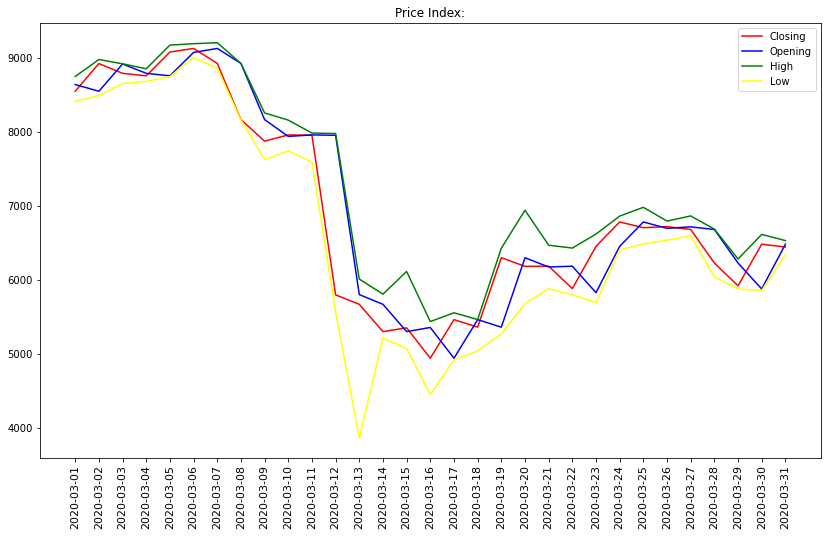

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index:')
plt.plot(covid.Date, covid.Closing, label='Closing', color='red')
plt.plot(covid.Date, covid.Opening, label='Opening', color='blue')
plt.plot(covid.Date, covid.High, label='High', color='green')
plt.plot(covid.Date, covid.Low, label='Low', color='yellow')

plt.xticks(covid.Date, rotation='vertical', size=11)
plt.legend()

plt.show()

The price started to dip below \\$8,000 after Black Monday (9th March) and went below \\$6,000 on Black Thursday (12th March) before hitting the lowest of the lows at \\$3867.091312. It would close above \\$5,000, but the fallout from the crash showed. Bitcoin's daily low would not get past \\$6,000 until 24th March.

### How long did it take for Bitcoin to recover?

In [41]:
postcovid = bitcoindata.loc[(bitcoindata['Monthly'] > '202003')]

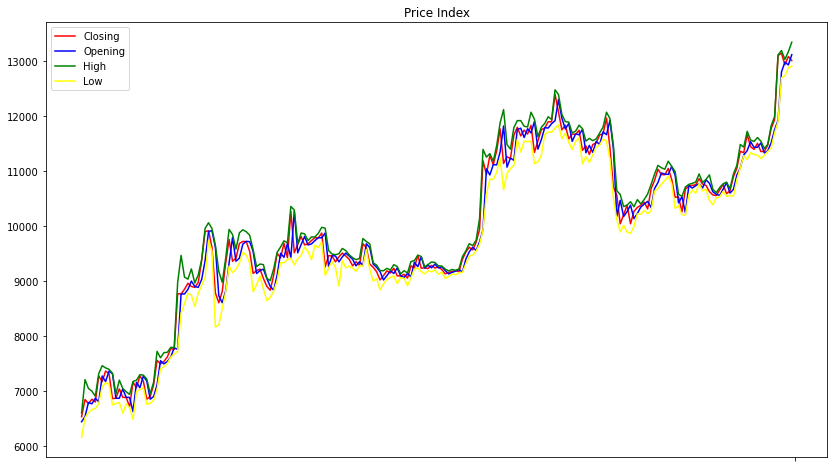

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(postcovid.Date, postcovid.Closing, label='Closing', color='red')
plt.plot(postcovid.Date, postcovid.Opening, label='Opening', color='blue')
plt.plot(postcovid.Date, postcovid.High, label='High', color='green')
plt.plot(postcovid.Date, postcovid.Low, label='Low', color='yellow')

plt.xticks('')
plt.legend()

plt.show()

In [43]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202004')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2365,BTC,2020-04-01,6537.336462,6446.442667,6605.444456,6159.582451,2020,202004,2020Q2
2366,BTC,2020-04-02,6850.558712,6537.686990,7212.725146,6519.934899,2020,202004,2020Q2
2367,BTC,2020-04-03,6776.370094,6796.925196,7049.706366,6612.677956,2020,202004,2020Q2
2368,BTC,2020-04-04,6855.933264,6772.007301,7003.126134,6664.610805,2020,202004,2020Q2
2369,BTC,2020-04-05,6805.362287,6873.720048,6908.855128,6684.715732,2020,202004,2020Q2
2370,BTC,2020-04-06,7278.243970,6809.004568,7319.978093,6775.111014,2020,202004,2020Q2
2371,BTC,2020-04-07,7175.667477,7277.704282,7464.732245,7081.639209,2020,202004,2020Q2
2372,BTC,2020-04-08,7367.293398,7175.669418,7424.743721,7155.211053,2020,202004,2020Q2
2373,BTC,2020-04-09,7321.816614,7366.900961,7399.469133,7125.775519,2020,202004,2020Q2
2374,BTC,2020-04-10,6866.398189,7321.815746,7325.324778,6752.593664,2020,202004,2020Q2


In [44]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202005')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2395,BTC,2020-05-01,8853.774484,8767.672143,9073.817530,8593.380363,2020,202005,2020Q2
2396,BTC,2020-05-02,8963.057558,8850.788756,9037.341927,8780.037925,2020,202005,2020Q2
2397,BTC,2020-05-03,8904.713817,9002.396916,9223.385534,8747.433419,2020,202005,2020Q2
2398,BTC,2020-05-04,8887.505893,8904.559394,8968.532234,8539.511107,2020,202005,2020Q2
2399,BTC,2020-05-05,8978.283587,8887.507473,9112.866151,8784.099590,2020,202005,2020Q2
2400,BTC,2020-05-06,9371.684273,9032.183227,9392.635447,8927.777068,2020,202005,2020Q2
2401,BTC,2020-05-07,9900.678867,9371.679970,9958.733998,9065.921045,2020,202005,2020Q2
2402,BTC,2020-05-08,9917.248414,9903.830754,10062.715915,9732.806548,2020,202005,2020Q2
2403,BTC,2020-05-09,9617.518195,9917.253174,9957.110928,9546.040993,2020,202005,2020Q2
2404,BTC,2020-05-10,8786.655182,9616.377064,9650.018603,8166.492188,2020,202005,2020Q2


6th May.

It took a month and a half for Bitcoin to regain its February and pre-COVID value. It would have a very small lull before hitting past \\$10,000 again.

### How long before it consistenly went past \\$10,000 again?

In [45]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202006')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2426,BTC,2020-06-01,10268.581985,9427.232535,10357.789166,9417.354212,2020,202006,2020Q2
2427,BTC,2020-06-02,9516.135443,10268.231877,10292.703097,9298.920950,2020,202006,2020Q2
2428,BTC,2020-06-03,9667.060754,9516.379828,9680.206444,9406.971187,2020,202006,2020Q2
2429,BTC,2020-06-04,9811.367095,9667.085402,9875.662127,9472.251048,2020,202006,2020Q2
2430,BTC,2020-06-05,9659.661298,9811.829378,9860.231447,9619.617459,2020,202006,2020Q2
2431,BTC,2020-06-06,9677.050995,9659.053118,9736.271128,9542.773398,2020,202006,2020Q2
2432,BTC,2020-06-07,9737.458559,9677.050684,9804.446487,9392.842926,2020,202006,2020Q2
2433,BTC,2020-06-08,9791.927900,9737.457447,9803.573516,9652.310114,2020,202006,2020Q2
2434,BTC,2020-06-09,9786.142020,9790.073884,9870.519387,9610.024354,2020,202006,2020Q2
2435,BTC,2020-06-10,9874.967048,9787.914131,9979.715526,9711.859580,2020,202006,2020Q2


In [46]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202007')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2456,BTC,2020-07-01,9236.316770,9141.348260,9300.998983,9096.778646,2020,202007,2020Q3
2457,BTC,2020-07-02,9097.797366,9240.169628,9267.123022,8957.632801,2020,202007,2020Q3
2458,BTC,2020-07-03,9094.324561,9097.683628,9132.985825,9065.858012,2020,202007,2020Q3
2459,BTC,2020-07-04,9124.653534,9067.937487,9190.818987,9051.870726,2020,202007,2020Q3
2460,BTC,2020-07-05,9055.464483,9141.075070,9149.765584,8919.762981,2020,202007,2020Q3
2461,BTC,2020-07-06,9278.805637,9078.614127,9356.327421,9063.727627,2020,202007,2020Q3
2462,BTC,2020-07-07,9244.415815,9344.987626,9374.083533,9216.518048,2020,202007,2020Q3
2463,BTC,2020-07-08,9471.759973,9262.805251,9472.080067,9239.543297,2020,202007,2020Q3
2464,BTC,2020-07-09,9236.143254,9444.728112,9449.911243,9173.165154,2020,202007,2020Q3
2465,BTC,2020-07-10,9243.175259,9239.473351,9260.349785,9133.962338,2020,202007,2020Q3


A full two months! 27th July marked the beginning of Bitcoin surging past \\$10,000 and landed at \\$11,000. This would continue on for a bit longer.

### What did the price index look like during the post-COVID recovery?

In [47]:
recentrecovery = bitcoindata.loc[(bitcoindata['Monthly'] >= '202005') & (bitcoindata['Monthly'] <= '202007')]

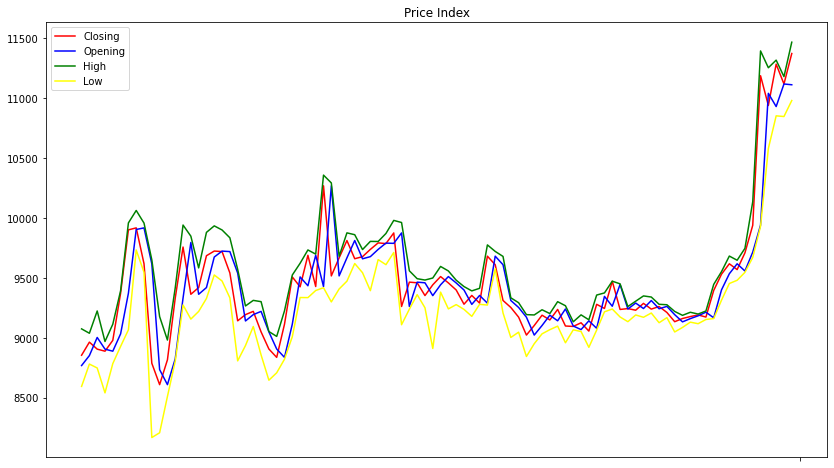

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(recentrecovery.Date, recentrecovery.Closing, label='Closing', color='red')
plt.plot(recentrecovery.Date, recentrecovery.Opening, label='Opening', color='blue')
plt.plot(recentrecovery.Date, recentrecovery.High, label='High', color='green')
plt.plot(recentrecovery.Date, recentrecovery.Low, label='Low', color='yellow')

plt.xticks('')
plt.legend()

plt.show()

The recovery did break past \\$10,000 once, but overall it stayed slightly above \\$9,000.

### How long did this new post-COVID peak last before readjusting?

In [49]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202008')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2487,BTC,2020-08-01,11766.748297,11352.715036,11880.773635,11241.976773,2020,202008,2020Q3
2488,BTC,2020-08-02,11139.098380,11820.512913,12117.677084,10658.946078,2020,202008,2020Q3
2489,BTC,2020-08-03,11261.806332,11071.267108,11480.283382,10956.562911,2020,202008,2020Q3
2490,BTC,2020-08-04,11228.026324,11237.224514,11400.064190,11045.968418,2020,202008,2020Q3
2491,BTC,2020-08-05,11653.407586,11196.287457,11791.103227,11107.135199,2020,202008,2020Q3
2492,BTC,2020-08-06,11796.817365,11756.894858,11917.765041,11581.575133,2020,202008,2020Q3
2493,BTC,2020-08-07,11639.935410,11780.044006,11917.859154,11347.412794,2020,202008,2020Q3
2494,BTC,2020-08-08,11744.912076,11610.908695,11814.956658,11543.347697,2020,202008,2020Q3
2495,BTC,2020-08-09,11673.123238,11770.450975,11802.662927,11536.752858,2020,202008,2020Q3
2496,BTC,2020-08-10,11832.227308,11693.179447,12070.441820,11546.957757,2020,202008,2020Q3


In [50]:
bitcoindata.loc[(bitcoindata['Monthly'] == '202009')]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2518,BTC,2020-09-01,11964.208672,11661.427339,12070.227406,11544.420032,2020,202009,2020Q3
2519,BTC,2020-09-02,11427.702605,11923.199640,11954.162680,11217.453831,2020,202009,2020Q3
2520,BTC,2020-09-03,10712.920646,11409.726335,11470.807021,10505.146810,2020,202009,2020Q3
2521,BTC,2020-09-04,10563.896939,10177.721642,10644.241174,10118.718611,2020,202009,2020Q3
2522,BTC,2020-09-05,10042.854854,10470.026686,10574.307306,9894.225400,2020,202009,2020Q3
2523,BTC,2020-09-06,10207.605003,10174.863432,10355.652495,10014.277661,2020,202009,2020Q3
2524,BTC,2020-09-07,10381.776107,10265.742989,10383.119236,9891.734243,2020,202009,2020Q3
2525,BTC,2020-09-08,10043.196441,10381.676816,10444.171125,9868.937984,2020,202009,2020Q3
2526,BTC,2020-09-09,10268.460916,10136.560835,10352.415189,9989.510556,2020,202009,2020Q3
2527,BTC,2020-09-10,10341.015984,10230.635528,10483.561208,10224.037393,2020,202009,2020Q3


That puts it at slightly over a full month. From late July to early September the price of Bitcoin was consistently over \\$11,000. The price readjusted, but it's still trending at a positive direction.

### What did the price index look like during the first post-COVID peak?

In [51]:
recentpeak = bitcoindata.loc[(bitcoindata['Date'] > '2020-07-25') & (bitcoindata['Date'] < '2020-09-05')]

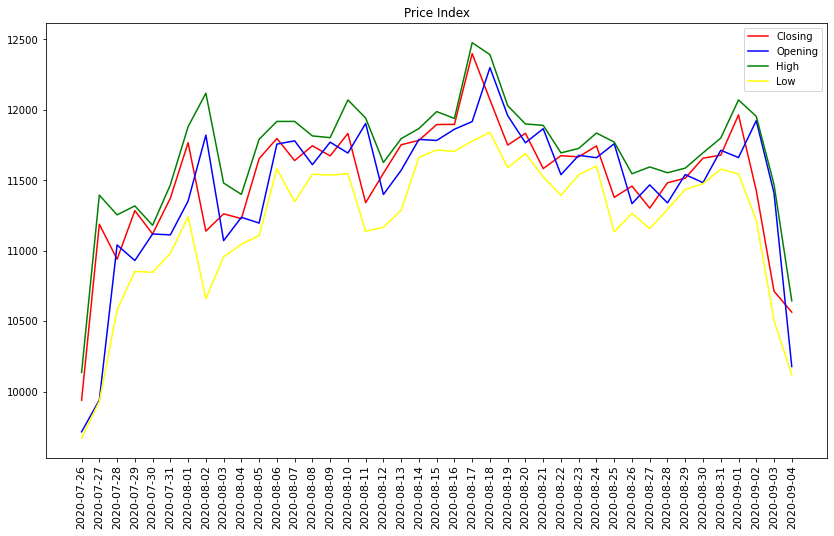

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(recentpeak.Date, recentpeak.Closing, label='Closing', color='red')
plt.plot(recentpeak.Date, recentpeak.Opening, label='Opening', color='blue')
plt.plot(recentpeak.Date, recentpeak.High, label='High', color='green')
plt.plot(recentpeak.Date, recentpeak.Low, label='Low', color='yellow')

plt.xticks(recentpeak.Date, rotation='vertical', size=11)
plt.legend()

plt.show()

For two days it broke the \\$12,000 barrier, but it mostly stayed around \\$11,000 for the duration of the post-COVID new peak. As mentioned by Bloomberg, this peak does come with some volatility, including a \\$1,500 drop in 30 minutes on 2nd August:

https://www.bloomberg.com/news/articles/2020-08-02/bitcoin-surpasses-12-000-then-tumbles-in-wild-weekend-action

### Looking at the price index again, when did the second post-COVID peak start?

In [53]:
bitcoindata.loc[(bitcoindata['Date'] > '2020-09-03') & (bitcoindata['Closing'] > 11000)]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly
2533,BTC,2020-09-16,11033.383526,10792.310233,11103.796477,10683.790263,2020,202009,2020Q3
2536,BTC,2020-09-19,11048.879278,10940.134471,11180.395306,10904.199618,2020,202009,2020Q3
2556,BTC,2020-10-09,11052.395084,10929.592619,11106.334456,10843.474299,2020,202010,2020Q4
2557,BTC,2020-10-10,11360.852717,11059.813566,11484.164484,11058.740486,2020,202010,2020Q4
2558,BTC,2020-10-11,11334.026742,11293.207011,11436.211481,11282.503558,2020,202010,2020Q4
2559,BTC,2020-10-12,11666.211700,11372.109958,11723.643859,11210.861339,2020,202010,2020Q4
2560,BTC,2020-10-13,11443.732792,11534.609567,11564.640059,11333.534919,2020,202010,2020Q4
2561,BTC,2020-10-14,11395.547366,11431.094044,11540.064925,11302.777036,2020,202010,2020Q4
2562,BTC,2020-10-15,11504.549007,11433.457538,11610.250397,11291.898092,2020,202010,2020Q4
2563,BTC,2020-10-16,11355.160439,11511.902199,11544.486009,11227.071057,2020,202010,2020Q4


It has been ongoing since the 21st October as Bitcoin closes around \\$13,000.

### What does the price index look like now?

In [54]:
currentpeak = bitcoindata.loc[(bitcoindata['Date'] >= '2020-10-16')]

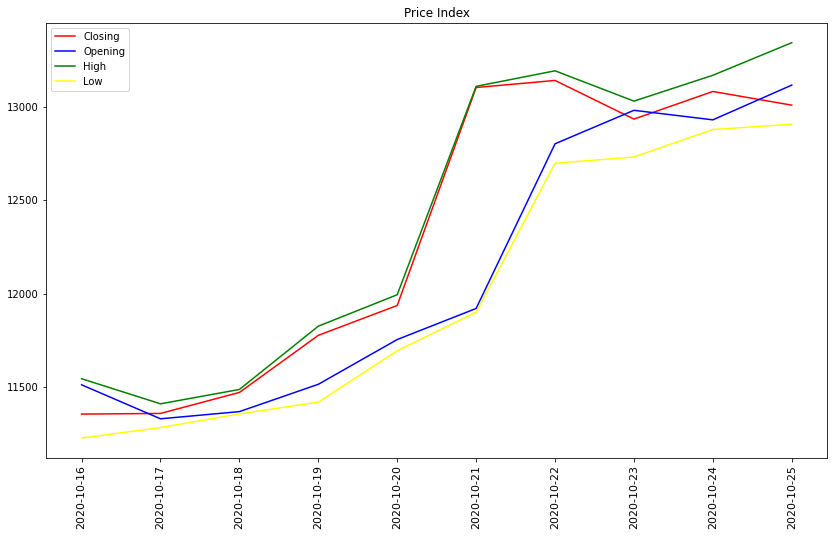

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(currentpeak.Date, currentpeak.Closing, label='Closing', color='red')
plt.plot(currentpeak.Date, currentpeak.Opening, label='Opening', color='blue')
plt.plot(currentpeak.Date, currentpeak.High, label='High', color='green')
plt.plot(currentpeak.Date, currentpeak.Low, label='Low', color='yellow')

plt.xticks(currentpeak.Date, rotation='vertical', size=11)
plt.legend()

plt.show()

Going back the last 10 days, the rise started happening on the 20th, had some volatility on the 21st, and leveled after that.

Before we get into volatility, let's move onto some questions regarding prices benchmarks that Bitcoin hit.

### How many days did the price of Bitcoin close at over \\$5000? \\$10000? \\$15000?

In [56]:
bitcoindata.loc[(bitcoindata['Closing'] > 5000)].count()

Currency     965
Date         965
Closing      965
Opening      965
High         965
Low          965
Yearly       965
Monthly      965
Quarterly    965
dtype: int64

965 out of 2573 days at over \\$5,000.

In [57]:
bitcoindata.loc[(bitcoindata['Closing'] > 10000)].count()

Currency     255
Date         255
Closing      255
Opening      255
High         255
Low          255
Yearly       255
Monthly      255
Quarterly    255
dtype: int64

255 out of 2573 days at over \\$10,000.

In [58]:
bitcoindata.loc[(bitcoindata['Closing'] > 15000)].count()

Currency     19
Date         19
Closing      19
Opening      19
High         19
Low          19
Yearly       19
Monthly      19
Quarterly    19
dtype: int64

19 out of 2573 days at over \\$15,000.

### Defining volatility as the difference between daily highs and lows, what does the volatility look like throughout the entirety of the price index?

In order to do that, let's add another column called 'Volatility', and that will be the difference between daily highs and lows.

In [59]:
bitcoindata['Volatility'] = bitcoindata['High'] - bitcoindata['Low']
bitcoindata

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly,Volatility
0,BTC,2013-09-30,123.654990,124.304660,124.751660,122.563490,2013,201309,2013Q3,2.188170
1,BTC,2013-10-01,125.455000,123.654990,125.758500,123.633830,2013,201310,2013Q4,2.124670
2,BTC,2013-10-02,108.584830,125.455000,125.665660,83.328330,2013,201310,2013Q4,42.337330
3,BTC,2013-10-03,118.674660,108.584830,118.675000,107.058160,2013,201310,2013Q4,11.616840
4,BTC,2013-10-04,121.338660,118.674660,121.936330,118.005660,2013,201310,2013Q4,3.930670
...,...,...,...,...,...,...,...,...,...,...
2568,BTC,2020-10-21,13102.934462,11920.411389,13109.165972,11900.213839,2020,202010,2020Q4,1208.952133
2569,BTC,2020-10-22,13140.669284,12801.688068,13192.252868,12697.457047,2020,202010,2020Q4,494.795821
2570,BTC,2020-10-23,12933.823565,12980.880103,13029.963892,12731.057793,2020,202010,2020Q4,298.906099
2571,BTC,2020-10-24,13081.672559,12929.849401,13168.338828,12877.938014,2020,202010,2020Q4,290.400814


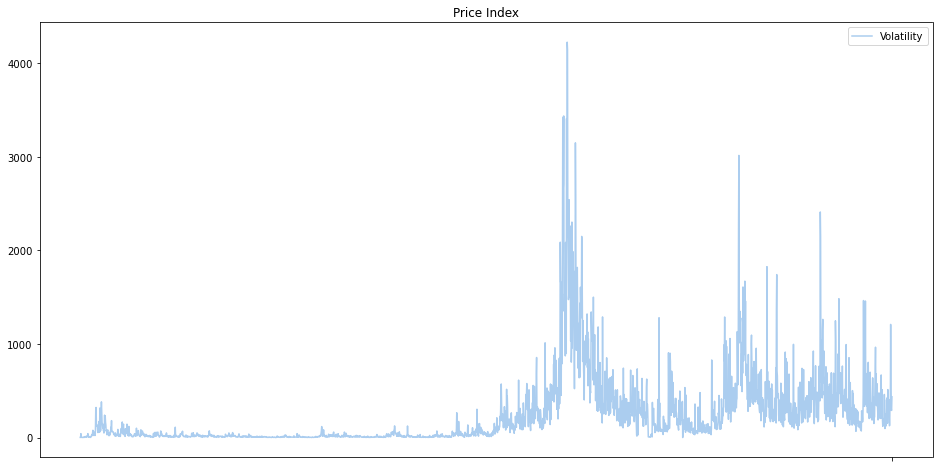

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

plt.title('Price Index')
plt.plot(bitcoindata.Date, bitcoindata.Volatility, label='Volatility', color='#abcdef')

plt.xticks('')
plt.legend()

plt.show()

The flat era is truly flat here as it shows the volatility to be very minimal. Subsequent peaks are indicators of price distortions in the market.

### What were the top ten days where the volatility the greatest?

In [61]:
bitcoindata.sort_values('Volatility',ascending=False).head(10)

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly,Volatility
1543,BTC,2017-12-21,14182.464990,16925.017500,17301.211250,13077.936660,2017,201712,2017Q4,4223.274590
1544,BTC,2017-12-22,14694.582500,14182.464990,14976.256250,10834.943750,2017,201712,2017Q4,4141.312500
1532,BTC,2017-12-10,16299.297500,13152.528750,16587.842500,13152.528750,2017,201712,2017Q4,3435.313750
1529,BTC,2017-12-07,16403.421250,13734.520000,17153.941250,13731.820000,2017,201712,2017Q4,3422.121250
1541,BTC,2017-12-19,16862.571250,18984.767500,18984.767500,15577.742500,2017,201712,2017Q4,3407.025000
1569,BTC,2018-01-16,10870.168750,12915.116250,13211.246250,10063.117500,2018,201801,2018Q1,3148.128750
2087,BTC,2019-06-27,11086.268829,12444.922343,13328.580313,10314.753873,2019,201906,2019Q2,3013.826439
1531,BTC,2017-12-09,13152.528750,15732.100000,15859.423750,13152.528750,2017,201712,2017Q4,2706.895000
1530,BTC,2017-12-08,15732.100000,16403.421250,16590.213750,13963.528750,2017,201712,2017Q4,2626.685000
1570,BTC,2018-01-17,11340.650000,10870.168750,11764.136250,9199.592500,2018,201801,2018Q1,2564.543750


Not surprising that nine out of the top ten days were in December 2017 and January 2018. The last date was during the summer of 2019 when there were news that regulators were looking into cryptocurrency as a whole.

### What was the cause of the third and final peak of volatility?

In [62]:
bitcoindata.sort_values('Volatility',ascending=False).head(20)[10:20]

,Currency,Date,Closing,Opening,High,Low,Yearly,Monthly,Quarterly,Volatility
1549,BTC,2017-12-27,14362.403750,15846.073750,16476.180000,13935.615000,2017,201712,2017Q4,2540.565000
2345,BTC,2020-03-12,5800.208905,7954.440008,7977.843680,5568.016690,2020,202003,2020Q1,2409.826991
1558,BTC,2018-01-05,16576.696250,14953.852500,17118.356250,14816.508750,2018,201801,2018Q1,2301.847500
1555,BTC,2018-01-02,14881.545000,13337.621250,15216.756250,12955.965000,2018,201801,2018Q1,2260.791250
2086,BTC,2019-06-26,12444.925860,11668.665857,13879.237706,11625.881090,2019,201906,2019Q2,2253.356616
1545,BTC,2017-12-23,14103.218750,14694.582500,15704.346250,13483.457500,2017,201712,2017Q4,2220.888750
1589,BTC,2018-02-05,6332.370000,8136.390000,8346.906250,6197.980000,2018,201802,2018Q1,2148.926250
2346,BTC,2020-03-13,5672.681201,5803.794314,6013.252892,3867.091312,2020,202003,2020Q1,2146.161580
1542,BTC,2017-12-20,16925.017500,16862.571250,17822.566250,15683.861250,2017,201712,2017Q4,2138.705000
1521,BTC,2017-11-29,10542.662500,10295.622500,11377.333750,9290.296250,2017,201711,2017Q4,2087.037500


COVID-19. The crash during March 12th and 13th were directly because of it.

### How many days was the daily difference at over \\$100? \\$500? \\$1000?

In [63]:
bitcoindata.loc[(bitcoindata['Volatility'] > 100)].count()

Currency      1172
Date          1172
Closing       1172
Opening       1172
High          1172
Low           1172
Yearly        1172
Monthly       1172
Quarterly     1172
Volatility    1172
dtype: int64

1172 out of 2557 days at over \\$100.

In [64]:
bitcoindata.loc[(bitcoindata['Volatility'] > 500)].count()

Currency      332
Date          332
Closing       332
Opening       332
High          332
Low           332
Yearly        332
Monthly       332
Quarterly     332
Volatility    332
dtype: int64

332 out of 2557 days at over \\$500.

In [65]:
bitcoindata.loc[(bitcoindata['Volatility'] > 1000)].count()

Currency      110
Date          110
Closing       110
Opening       110
High          110
Low           110
Yearly        110
Monthly       110
Quarterly     110
Volatility    110
dtype: int64

110 out of 2557 days at over \\$1,000.

### How does that volatility look at a monthly, quarterly, and yearly basis?

In [66]:
monthlyvolatility = bitcoindata.groupby(['Monthly']).mean()['Volatility']

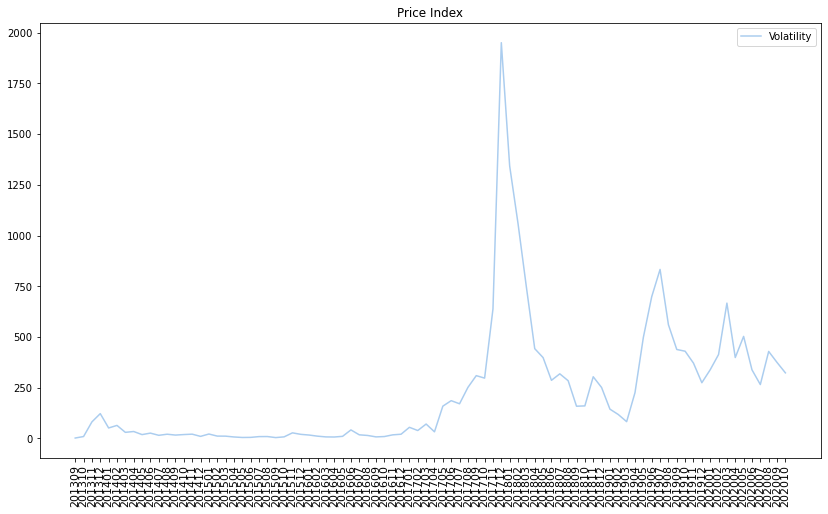

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(monthlyvolatility, label='Volatility', color='#abcdef')

plt.xticks(rotation='vertical', size=11)
plt.legend()

plt.show()

In [68]:
bitcoindata.groupby(['Monthly']).mean()[['High','Low','Volatility']][:43]

,High,Low,Volatility
Monthly,,,
201309,124.751660,122.563490,2.188170
201310,154.576018,144.982100,9.593918
201311,560.034675,478.247872,81.786803
201312,856.563876,734.056323,122.507553
201401,881.562527,829.781661,51.780865
201402,690.957171,626.554146,64.403026
201403,606.441181,576.165398,30.275783
201404,475.581242,441.221584,34.359657
201405,492.354471,473.246542,19.107929


In [69]:
bitcoindata.groupby(['Monthly']).mean()[['High','Low','Volatility']][43:]

,High,Low,Volatility
Monthly,,,
201704,1231.560965,1198.746114,32.814851
201705,1963.131626,1803.801975,159.329651
201706,2742.598360,2556.193332,186.405028
201707,2601.907498,2430.852983,171.054515
201708,4009.102175,3757.515913,251.586262
201709,4236.124499,3926.388583,309.735916
201710,5451.353911,5153.793346,297.560565
201711,8092.623875,7454.319458,638.304417
201712,15781.762258,13830.786786,1950.975471


After having a volatility of over \\$100 in December 2013, Bitcoin would spend the next two and a half years below that amount before only doing so again in March 2019. Since May 2017, the average daily difference averages well over \\$100, reaching as high as over \\$1,000 from December 2017 to February 2018.

In [70]:
quarterlyvolatility = bitcoindata.groupby(['Quarterly']).mean()['Volatility']

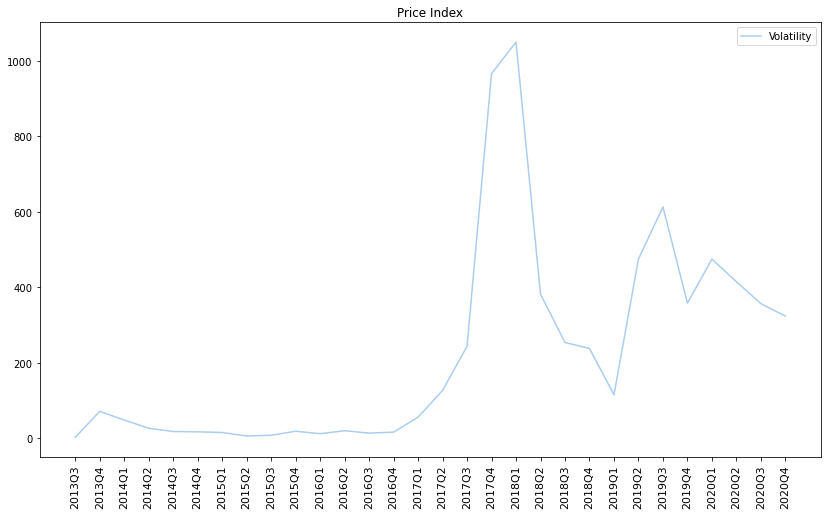

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(quarterlyvolatility, label='Volatility', color='#abcdef')

plt.xticks(rotation='vertical', size=11)
plt.legend()

plt.show()

In [72]:
bitcoindata.groupby(['Quarterly']).mean()[['High','Low','Volatility']]

,High,Low,Volatility
Quarterly,,,
2013Q3,124.751660,122.563490,2.188170
2013Q4,523.330185,452.148122,71.182062
2014Q1,727.499064,679.198610,48.300453
2014Q2,530.334669,503.783592,26.551077
2014Q3,541.214646,523.416657,17.797989
2014Q4,364.424239,347.502722,16.921517
2015Q1,259.069906,243.898176,15.171730
2015Q2,239.374382,233.453050,5.921331
2015Q3,258.594095,250.849294,7.744802


There were 15 quarters of remaining below \\$100, and 2019Q1 almost made 16th on the list.

In [73]:
yearlyvolatility = bitcoindata.groupby(['Yearly']).mean()['Volatility']

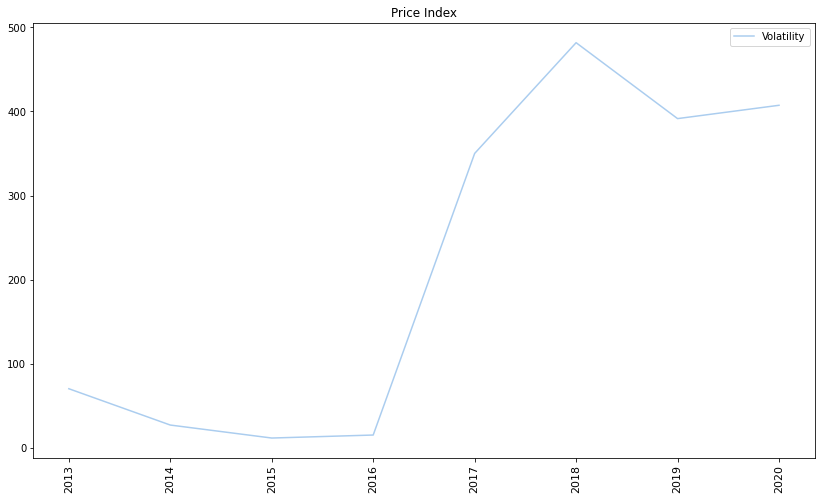

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.title('Price Index')
plt.plot(yearlyvolatility, label='Volatility', color='#abcdef')

plt.xticks(rotation='vertical', size=11)
plt.legend()

plt.show()

In [75]:
bitcoindata.groupby(['Yearly']).mean()[['High','Low','Volatility']]

,High,Low,Volatility
Yearly,,,
2013,519.044394,448.604202,70.440192
2014,539.874378,512.593876,27.280502
2015,278.182428,266.335513,11.846915
2016,573.977324,558.570542,15.406782
2017,4132.673853,3782.607896,350.065957
2018,7780.823214,7299.147779,481.675435
2019,7538.928398,7147.470331,391.458067
2020,9571.426436,9164.143369,407.283067


Yearly averages show an even split between the years in both the overall price and its differences. The annual average its first four years was never above \\$1,000, and its average was also never above \\$100. This flipped the last four years start at 2017 where the annual average was 23x higher than the previous year.

## Credits
Official data: https://www.coindesk.com/price/bitcoin <br>
Last retrieved: 25th October, 2020.